In [2]:
%cd ..
from experiment_control.srs_microscope.srs_microscope import *

C:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


C:\Users\euyehara
Opening connnection to Keithley source meter
Opening connection to Agilent E3633A DC Power Supply


In [2]:
center_spot()

In [5]:
cam.close()

In [17]:
#Test DAQ VCSEL continuous sweep
sample_dir = 'Test_DAQ_VCSEL_sweep'
# name = 'diamond_sweep_VOA_wavvolt-trunc_OE71mW_Dev1a8.5mW_best'
name = 'calib_HVA'

t_lia = 10*u.ms
sens_lia = 300 * u.uV
wav_start = 1253*u.nm
wav_stop = 1290*u.nm
Δwav = 0.1*u.nm 
num_sweep = 5
fixed_wav = 1075.6*u.nm

calib_dir = 'C:\\Users\\euyehara\\experiment_control\\calibration_data\\VCSEL_calibration\\'
wavvolt_file = calib_dir + 'wavvolt-trunc_Dev1a_25C_OEland1076_5.72mW_2025-3-17.mat'
delayvolt_file = calib_dir + 'delayvolt3.mat'

ds = VCSEL_sweep_spectrum(wavvolt_file, delayvolt_file, num_sweep, t_lia, sens_lia, wav_start, wav_stop, Δwav, fixed_wav, sample_dir=sample_dir, name=name)

saving data to: 
C:\Users\euyehara\Documents\data\srs_microscope\Sample_Test_DAQ_VCSEL_sweep_2025-03-25-18-27-43\Spectra_calib_HVA_2025-03-26-00-49-54.h5
dumping item: num_sweep
non-array, non-list item without units
dumping item: t_lia
non-array, non-list item with units:
millisecond
dumping item: sens_lia
non-array, non-list item with units:
microvolt
dumping item: wav_start
non-array, non-list item with units:
nanometer
dumping item: wav_stop
non-array, non-list item with units:
nanometer
dumping item: Δwav
non-array, non-list item with units:
nanometer
dumping item: wavelength_set
dumping item: pump_wav
non-array, non-list item with units:
nanometer
sweep time: 152.04 second
start time: Wed Mar 26 00:49:54 2025
stop time: Wed Mar 26 00:52:26 2025
dumping item: Dev2/ao1
dumping item: Dev2/ao0
dumping item: Dev2/ai0
dumping item: Dev2/ai1
dumping item: t
dumping item: Vsrs_arr
dumping item: HV_arr
dumping item: wav_est_arr
dumping item: Vsrs_interp_arr
dumping item: HVA_Vraw
dumping 

In [2]:
osa = initialize_osa(ref_level = -43*u.dimensionless, wav_start=1050*u.nm, wav_stop = 1300*u.nm)

In [16]:
#Test DAQ VCSEL step sweep
sample_dir = 'Test_DAQ_VCSEL_sweep'
# name = 'diamond_sweep_VOA_wavvolt-trunc_OE71mW_Dev1a8.5mW_best'
name = 'test_fix'

t_lia = 30*u.ms
sens_lia = 300 * u.uV
wav_start = 1253*u.nm
wav_stop = 1290*u.nm
Δwav = 10*u.nm 
wav_settle_time = 0.3*u.s
num_avg = 5
fixed_wav = 1075.6*u.nm

calib_dir = 'C:\\Users\\euyehara\\experiment_control\\calibration_data\\VCSEL_calibration\\'
wavvolt_file = calib_dir + 'wavvolt-trunc_Dev1a_25C_OEland1076_5.72mW_2025-3-17.mat'
delayvolt_file = calib_dir + 'delayvolt3.mat'


ds = VCSEL_step_spectrum(osa, wavvolt_file, delayvolt_file, num_avg, t_lia, sens_lia, wav_start, wav_stop, Δwav, fixed_wav, wav_settle_time=1*u.s,sample_dir=sample_dir, name=name)

NameError: name 'osa' is not defined

In [18]:
def HVA_to_daq(HVA_volt, atten=0.09128, volt_limit=70*u.V):
    # Convert the output HVA voltage (to VCSEL MEMS) to the daq input to the HVA
    # atten - from voltage divider between daq and HVA
    V_gain = 100 # For Trek 2210
    if HVA_volt > volt_limit:
        print(f"Vset= {HVA_volt:3.2f} exceeds Vlim= {volt_limit:3.2f}. Setting to 0 V.")
        HVA_volt = 0*u.V
    daq_volt = HVA_volt / V_gain / atten
    return daq_volt

HVA_volt = 0*u.V
daq_volt = HVA_to_daq(HVA_volt)
ch_VCSEL_MEMS.write(daq_volt)

# Single Wavelength Measurement

In [191]:
sample_dir = "PhotonicsWest-SNR-LIAnoiseMeas_diamond_SRL_point"
# name = "R_ycut-LN_DSP_Y(cZ)Y_30ms3uV_O110mW_S27mW_986"
name = "VaryDev1a_noise_SA-230F5_FGA21-25V_OE60mW_Dev1a0mW_3ms100uV"
# name = "OElandSweep_T_30ms3uV_120s_985_HWP_SHG-LP_50mW_noF-F"

t_lia = 3*u.ms
n_rep = 50
pump_wav = 1072.6*u.nm
stokes_wav = 1251.7*u.nm

ds_point = acquire_point(t_lia, n_rep, pump_wav, stokes_wav, sample_dir=sample_dir, name=name)


saving data to: 
C:\Users\euyehara\Documents\data\srs_microscope\Sample_PhotonicsWest-SNR-LIAnoiseMeas_diamond_SRL_point_2024-12-14-21-35-34\WavePoint_VaryDev1a_noise_SA-230F5_FGA21-25V_OE60mW_Dev1a0mW_3ms100uV_2024-12-15-16-39-49.h5
dumping item: t_lia
non-array, non-list item with units:
millisecond
dumping item: fsamp
non-array, non-list item with units:
hertz
dumping item: pump_wav
non-array, non-list item with units:
nanometer
dumping item: stokes_wav
non-array, non-list item with units:
nanometer
acquisition time: 600.00 millisecond
start time: Sun Dec 15 16:39:49 2024
stop time: Sun Dec 15 16:49:49 2024
dumping item: srs
loading file: WavePoint_VaryDev1a_noise_SA-230F5_FGA21-25V_OE60mW_Dev1a0mW_3ms100uV_2024-12-15-16-39-49.h5
importing srs...
importing attr fsamp...
hertz
importing attr fsamp_units...
importing attr pump_wav...
nanometer
importing attr pump_wav_units...
importing attr stokes_wav...
nanometer
importing attr stokes_wav_units...
importing attr t_lia...
millisecond


# Spectral Acquisition

In [3]:
osa = initialize_osa(ref_level = -43*u.dimensionless, wav_start=1050*u.nm, wav_stop = 1300*u.nm)


In [35]:
[pk_wls, _] = osa.get_peak_info()
print(pk_wls[0])
print(pk_wls[1])

1.0756e-06 meter
1.2631e-06 meter


In [5]:
span = 1300*u.nm - 1230*u.nm
center_wl = np.round(span/2) + 1250*u.nm
osa.set_wavelength_span(span)
osa.set_center_wavelength(center_wl)

In [8]:
span = 1090*u.nm - 1030*u.nm
center_wl = np.round(span/2) + 1030*u.nm
osa.set_wavelength_span(span)
osa.set_center_wavelength(center_wl)

In [22]:
sample_dir = 'Test_VCSEL_sweep'
name = 'diamond_sweep_VOA_wavvolt-trunc_OE71mW_Dev1a8.5mW_best'

t_lia = 30*u.ms
sens_lia = 300 * u.uV
wav_start = 1253*u.nm
wav_stop = 1290*u.nm
Δwav = 0.2*u.nm 
wav_settle_time = 0.3*u.s
num_avg = 5
fixed_wav = 1075.6*u.nm

calib_dir = 'C:\\Users\\euyehara\\experiment_control\\calibration_data\\VCSEL_calibration\\'
calib_dir = calib_dir + 'wavvolt-trunc_Dev1a_25C_OEland1076_5.72mW_2025-3-17.mat'
delayvolt_file = calib_dir + 'delayvolt3.mat'

ds_spec = acquire_spectrum(osa, wavvolt_file, delayvolt_file, num_avg, t_lia, sens_lia, wav_start, wav_stop, Δwav, fixed_wav, wav_settle_time=wav_settle_time, sample_dir=sample_dir, name=name)


saving data to: 
C:\Users\euyehara\Documents\data\srs_microscope\Sample_Test_VCSEL_sweep_CW_2025-03-21-16-46-04\Spectra_diamond_sweep_VOA_wavvolt-trunc_OE71mW_Dev1a8.5mW_best_2025-03-21-19-06-58.h5
dumping item: num_avg
non-array, non-list item without units
dumping item: t_lia
non-array, non-list item with units:
millisecond
dumping item: sens_lia
non-array, non-list item with units:
microvolt
dumping item: wav_start
non-array, non-list item with units:
nanometer
dumping item: wav_stop
non-array, non-list item with units:
nanometer
dumping item: Δwav
non-array, non-list item with units:
nanometer
dumping item: wav_settle_time
non-array, non-list item with units:
second
dumping item: wavelength_set
dumping item: fixed_wav
non-array, non-list item with units:
nanometer
sweep time: 304.00 second
start time: Fri Mar 21 19:07:08 2025
stop time: Fri Mar 21 19:12:12 2025
[55.3867 55.2758 55.1506 55.0389 54.927 54.8049 54.6926 54.5682 54.4564 54.3313 54.2193 54.0975 53.9855 53.8612 53.7367 53

In [21]:
rs = ds_spec["raman_shift"]
p_wl = ds_spec["pump_wl_meas"]
s_wl = ds_spec["stokes_wl_meas"]

    # raman_shift = (1 / pump_wl_meas  - 1 / stokes_wl_meas).to(1 / u.cm)

print(p_wl)
print(s_wl)

1.07583e-06 meter
[1.25581e-06 1.25581e-06 1.25695e-06 1.25634e-06 1.25739e-06 1.25739e-06 1.25774e-06 1.25783e-06 1.25739e-06 1.25826e-06 1.25783e-06 1.25783e-06 1.25826e-06 1.25826e-06 1.2587e-06 1.2587e-06 1.25879e-06 1.25914e-06 1.25923e-06 1.25958e-06 1.25966e-06 1.26071e-06 1.26063e-06 1.26106e-06 1.26063e-06 1.26071e-06 1.26115e-06 1.26106e-06 1.26202e-06 1.26159e-06 1.26246e-06 1.26246e-06 1.26202e-06 1.26246e-06 1.26246e-06 1.26255e-06 1.2629e-06 1.2629e-06 1.26404e-06 1.26343e-06 1.26448e-06 1.26448e-06 1.26482e-06 1.26491e-06 1.26526e-06 1.26535e-06 1.26491e-06 1.26587e-06 1.26535e-06 1.26631e-06 1.26579e-06 1.26579e-06 1.26623e-06 1.26623e-06 1.26631e-06 1.26675e-06 1.26771e-06 1.2678e-06 1.26728e-06 1.26833e-06 1.26771e-06 1.2678e-06 1.26824e-06 1.26911e-06 1.26911e-06 1.26867e-06 1.26964e-06 1.26964e-06 1.27008e-06 1.26964e-06 1.26964e-06 1.2706e-06 1.27008e-06 1.27008e-06 1.27113e-06 1.2706e-06 1.27156e-06 1.27104e-06 1.272e-06 1.27218e-06 1.27156e-06 1.27261e-06 1.27209

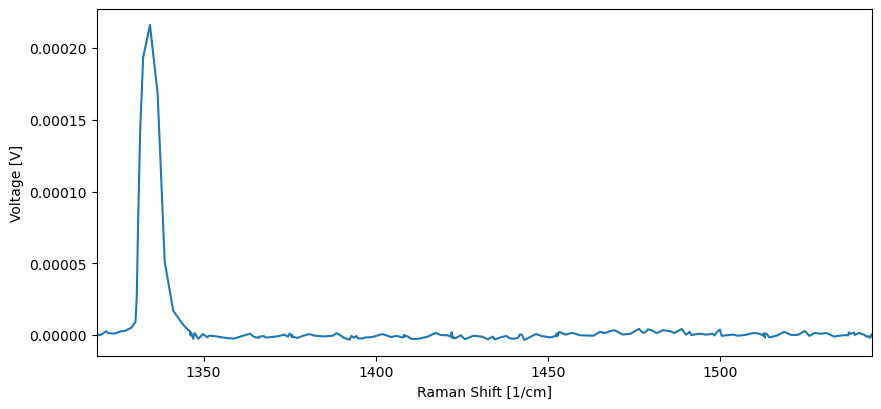

In [23]:
fig=plot_spectra(ds_spec, sg_win_len=10)


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21])

sample_dir = "T_ycut-LiNbO3_1mm_SSP"
name = "SolstisSweep_OEland_100ms10uV_HWP_SHG-LP"

t_lia = 100*u.ms
fsamp = (1/(4*t_lia)).to(u.Hz) 
wav_start = 950*u.nm
wav_stop = 989*u.nm
Δwav = 0.5*u.nm 
num_avg = 5
fixed_wav = 1037.69*u.nm
wav_settle_time = 0*u.s
ds_spec = acquire_spectrum(num_avg, fsamp, wav_start, wav_stop, Δwav, fixed_wav, wav_settle_time=wav_settle_time, sample_dir=sample_dir, name=name)


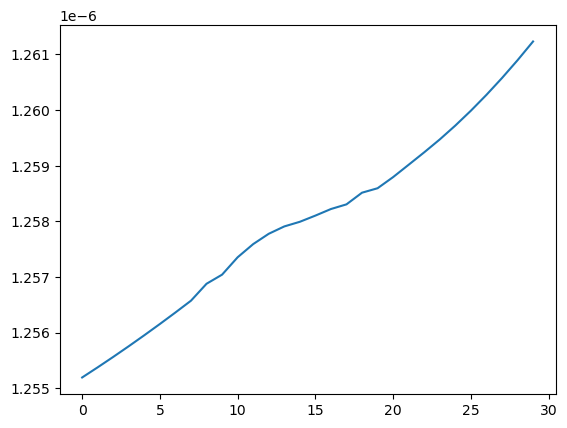

In [17]:
plt.figure()
ind_arr = np.arange(0, s_wl.shape[0],1)
s_wl = savgol_filter(ds_spec["stokes_wl_meas"].m, 15,2)*u.m
plt.plot(ind_arr,s_wl)

(781.005570616225, 1496.3134882674972)

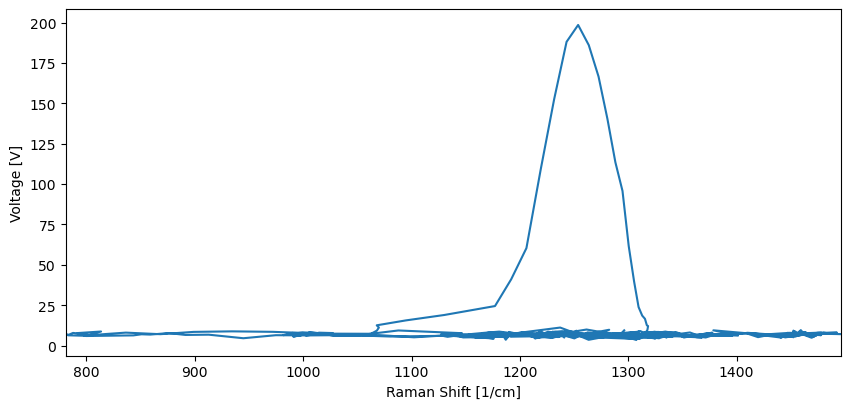

In [8]:
from scipy.signal import savgol_filter

figsize=(10,4.5)
# raman_shift = ds_spec["raman_shift"]
p_wl = np.mean(ds_spec["pump_wl_meas"].m)*u.m
s_wl = savgol_filter(ds_spec["stokes_wl_meas"].m, 50,2)*u.m
raman_shift = (1 / p_wl  - 1 / s_wl).to(1 / u.cm)
spec = ds_spec["spec"]
sensitivity = ds_spec["sens_lia"]
offset = 0 * u.V
spec_calib = (spec / 10 + offset) * (sensitivity).to(u.V).m
# tap_power = ds_spec["tap_power"]
wavelength_set = ds_spec["wavelength_set"]
# wavelength_meas = ds_spec["wavelength_meas"]

# Correct for wavelength-dependent power
# power_corr = tap_power.m / tap_power[0].m
# spec_corr = spec * power_corr

fig, ax = plt.subplots(1, 1, figsize=figsize)
ax.plot(raman_shift.m, spec_calib.to(u.uV).m)
ax.set_xlabel("Raman Shift [1/cm]")
ax.set_ylabel("Voltage [V]")
ax.set_xlim((np.min(raman_shift.m), np.max(raman_shift.m)))


In [4]:
cam.close()

In [3]:
t_lia = 30*u.ms
fsamp = (1/(3*t_lia)).to(u.Hz)
t_collect = 30*u.s
num_samp = np.round(t_collect.m / (1/fsamp).m)
print(num_samp)

333.0


In [4]:
fig = preview_scan_area(nx, ny, ΔVx, ΔVy, fsamp=fsamp, exposure_time=3*u.ms)

NameError: name 'nx' is not defined

# Continuous Sweep Spectrum

In [25]:
sample_dir2 = "Test_VCSEL_sweep_CW"
name = "noiseSig_diamond_1mV"

t_lia = 10*u.ms
sens_lia = 100*u.uV
t_sweep = 120*1*u.s
wav_start = 1037.9*u.nm
wav_stop = 1080*u.nm
fixed_wav = 1256.2*u.nm

# ds_spec = continuous_spectrum(t_lia, wav_start, wav_stop, fixed_wav, t_sweep=t_sweep,sample_dir=sample_dir2, name=name)
ds_spec = continuous_spectrum_tap(t_lia, sens_lia, wav_start, wav_stop, fixed_wav, t_sweep=t_sweep,sample_dir=sample_dir2, name=name)

saving data to: 
C:\Users\euyehara\Documents\data\srs_microscope\Sample_Test_VCSEL_sweep_CW_2025-03-21-16-46-04\SpectraSweep_noiseSig_diamond_1mV_2025-03-21-16-46-04.h5
dumping item: t_lia
non-array, non-list item with units:
millisecond
dumping item: fsamp
non-array, non-list item with units:
hertz
dumping item: wav_start
non-array, non-list item with units:
nanometer
dumping item: wav_stop
non-array, non-list item with units:
nanometer
dumping item: t_sweep
non-array, non-list item with units:
second
dumping item: fixed_wav
non-array, non-list item with units:
nanometer
sweep time: 120.00 second
start time: Fri Mar 21 16:46:04 2025
stop time: Fri Mar 21 16:48:04 2025
dumping item: spec
dumping item: wav_mon
dumping item: pump_tap
loading file: SpectraSweep_noiseSig_diamond_1mV_2025-03-21-16-46-04.h5
importing pump_tap...
importing spec...
importing wav_mon...
importing attr fixed_wav...
nanometer
importing attr fixed_wav_units...
importing attr fsamp...
hertz
importing attr fsamp_uni

In [5]:
import os

In [6]:
data_dir = os.path.join(home_dir,"Documents","data","srs_microscope")
print(data_dir)

C:\Users\euyehara\Documents\data\srs_microscope


C:\Users\Prismo\miniconda3\lib\site-packages\matplotlib\cbook\__init__.py:1333: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)
C:\Users\Prismo\miniconda3\lib\site-packages\matplotlib\cbook\__init__.py:1333: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


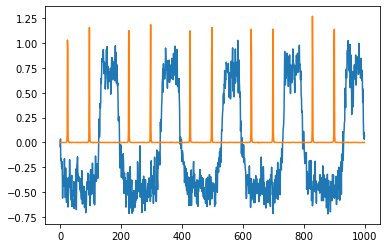

In [11]:
plt.figure()
plt.plot(ds_spec['spec'])
plt.plot(ds_spec['wav_mon'])

# Knife Edge Scan

In [4]:
cam.close()
stage = initialize_stage()
stage.connect()

Connecting to BPC203:
	- connecting to controller 71829423 --> done
	- connecting channel 1 (x axis) --> done
	- connecting channel 2 (y axis) --> done
	- connecting channel 3 (z axis) --> done




In [3]:
wf_illum_off()

In [5]:
pos = stage.get_axis_position('y')

In [79]:
stage.set_axis_position('y', 7)

	- moving y axis piezo to 7.000000 um --> done


In [90]:
stage.set_axis_position('y', 15)

	- moving y axis piezo to 15.000000 um --> done


In [91]:
stage.set_axis_position('y', 0)

	- moving y axis piezo to 0.000000 um --> done


σ = 1.33μm


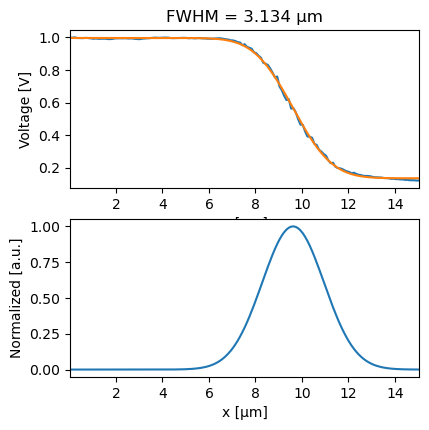

In [117]:
fig = plot_knife_scan(ds_spot)

In [116]:
scan_length = 15*u.um
axis = 'y'
step_size = 0.1*u.um
num_avg  = 3
# [ps_arr, pd_arr] = scan_single_axis(scan_length, axis, step_size, wait=0.5*u.s)
# ds_spot = knife_edge_scan(stage, scan_length, axis, step_size, num_avg=num_avg, sample_dir='Nikon20xR_y_SiAu', name='Solstis985_pos38')
ds_spot = knife_edge_scan(stage, scan_length, axis, step_size, num_avg=num_avg, sample_dir='BeamSpotMeas_Nikon20xT_y_GaAs', name='Dev1a-redo_Coverslip_pos47')

saving data to: 
C:\Users\euyehara\Documents\data\srs_microscope\Sample_BeamSpotMeas_Nikon20xT_y_GaAs_2024-12-14-12-14-28\knifeScan_Dev1a-redo_Coverslip_pos47_2024-12-14-17-53-04.h5
15.033570360423598
scan time: 302.00 second
start time: Sat Dec 14 17:53:04 2024
stop time: Sat Dec 14 17:58:06 2024
	- moving y axis piezo to 0.033570 um --> done
	- moving y axis piezo to 0.133570 um --> done
	- moving y axis piezo to 0.233570 um --> done
	- moving y axis piezo to 0.333570 um --> done
	- moving y axis piezo to 0.433570 um --> done
	- moving y axis piezo to 0.533570 um --> done
	- moving y axis piezo to 0.633570 um --> done
	- moving y axis piezo to 0.733570 um --> done
	- moving y axis piezo to 0.833570 um --> done
	- moving y axis piezo to 0.933570 um --> done
	- moving y axis piezo to 1.033570 um --> done
	- moving y axis piezo to 1.133570 um --> done
	- moving y axis piezo to 1.233570 um --> done
	- moving y axis piezo to 1.333570 um --> done
	- moving y axis piezo to 1.433570 um --> d

In [70]:
from scipy.signal import savgol_filter
def plot_knife_scan(ds_spot, figsize=(4.5,4.5)):
    """
    Extract beam waist from knife edge scan data
    Fits scan data to a gaussian cdf, extracts sigma and mu, then calculates FWHM of associated gaussian
    """
    x = ds_spot["pos_arr"].m
    # pd_arr = savgol_filter(ds_spot["pd_arr"].m / max(ds_spot["pd_arr"].m), 10,2)
    pd_arr = ds_spot["pd_arr"].m / max(ds_spot["pd_arr"].m)


    if pd_arr[0] > pd_arr[-1]:  # scanning from exposed to covered beam
        f = lambda x, mu, sigma, A, B: B + A * norm(mu, sigma).cdf(-x)
        gauss_fit = lambda x, mu, sigma: norm(mu, sigma).pdf(-x) / np.max(norm(mu, sigma).pdf(-x))
    elif pd_arr[-1] > pd_arr[0]:  # scanning from covered to exposed beam
        f = lambda x, mu, sigma, A, B: B + A * norm(mu, sigma).cdf(x)
        gauss_fit = lambda x, mu, sigma: norm(mu, sigma).pdf(x) / np.max(norm(mu, sigma).pdf(x))

    mu, sigma, A, B = curve_fit(f, x, pd_arr)[0]
    
    fwhm = 2 * sigma * np.sqrt(2 * np.log(2))
    print("σ = %2.2fμm" % sigma)

    fig, ax = plt.subplots(2, 1, figsize=figsize)
    ax[0].set_title("FWHM = %3.3f μm" % fwhm)
    ax[0].plot(x, pd_arr)
    ax[0].plot(x, f(x, mu, sigma, A, B))
    ax[0].set_xlabel("x [μm]")
    ax[0].set_ylabel("Voltage [V]")
    ax[0].set_xlim((np.min(x), np.max(x)))

    ax[1].plot(x, gauss_fit(x, mu, sigma))
    ax[1].set_xlabel("x [μm]")
    ax[1].set_ylabel("Normalized [a.u.]")
    ax[1].set_xlim((np.min(x), np.max(x)))

    return fig

In [ ]:
plt.figure()
plt.plot(ds_spot["pos_arr"].m, ds_spot["pd_arr"].m)
plt.show()

In [39]:
move_spot(0.3*u.volt, -0.3*u.volt)
#1.21m@ -> 0.77mA

In [40]:
move_spot(-0.3*u.volt, 0.3*u.volt)
#1.21mW -> 0.77mA

In [41]:
center_spot()
#1.21mW -> 0.89mA

In [34]:
# 0.77/1.2
# 1.1/1.625
# 2.95/6.4
3.07/6.2
3.76/7.65
1.3/3.4
2.14/4.3
1.88/3.7

0.508108108108108

# Galvo Scan

scan time: 120.00 second


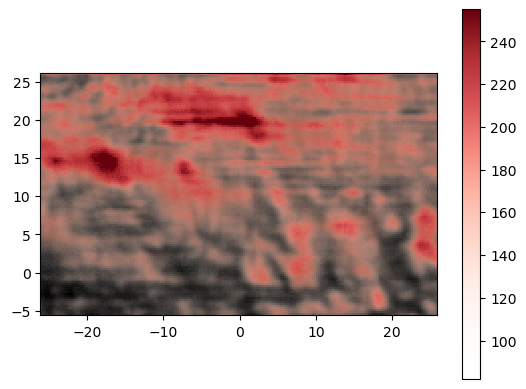

In [13]:
# Configure scan and preview scan area
# 3ms integration time
filename = "diamond_CWDev1a-22mW-1253.3_OEland1073.8-230mW_30uV10ms" 
sample_dir = "SRL_FDS100-25V_CWDev1a"

t_LIA = 3*u.ms
nx, ny      =   100   ,   100 #500          ,       500
ΔVx, ΔVy    =   0.3*u.volt   ,   0.3*u.volt #1.0*u.volt    ,      1.0*u.volt # 0.8*u.volt
fsamp       =   (1/(4*t_LIA)).to(u.Hz)#1000*u.Hz

fig = preview_scan_area(nx, ny, ΔVx, ΔVy, fsamp=fsamp, exposure_time=99*u.ms)

saving data to: 
C:\Users\euyehara\Documents\data\srs_microscope\Sample_SRL_FDS100-25V_CWDev1a_2024-11-12-21-47-19\GalvoScan_diamond_CWDev1a-22mW-1253.3_OEland1073.8-226mW_100uV10ms_2024-11-12-22-16-42.h5
dumping item: wf_img
dumping item: laser_spot_img
dumping item: dx_dpix
non-array, non-list item with units:
micrometer
dumping item: x_img
dumping item: y_img
dumping item: dx_dVx
non-array, non-list item with units:
micrometer / volt
dumping item: dy_dVy
non-array, non-list item with units:
micrometer / volt
dumping item: Vx0
non-array, non-list item with units:
volt
dumping item: Vy0
non-array, non-list item with units:
volt
scan time: 120.00 second
start time: Tue Nov 12 22:16:44 2024
stop time: Tue Nov 12 22:18:44 2024
dumping item: Dev1/ao0
dumping item: Dev1/ao1
dumping item: Dev1/ao2
dumping item: Dev1/ao3
dumping item: Dev1/ai0
dumping item: Dev1/ai2
dumping item: Dev1/ai3
dumping item: t
dumping item: Vx
dumping item: Vy
dumping item: dx_dVx
non-array, non-list item with uni

C:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\matplotlib\cbook.py:733: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  x = np.array(x, subok=True, copy=copy)


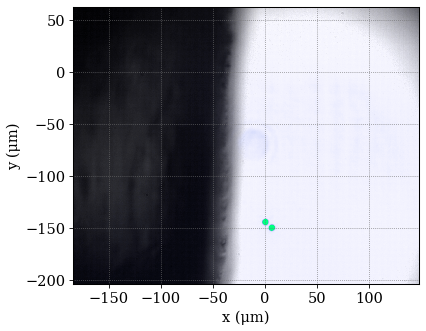

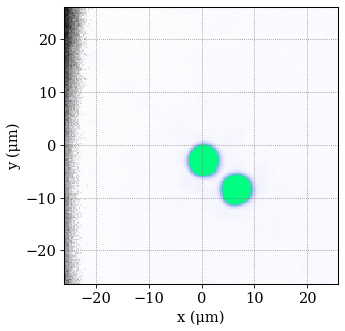

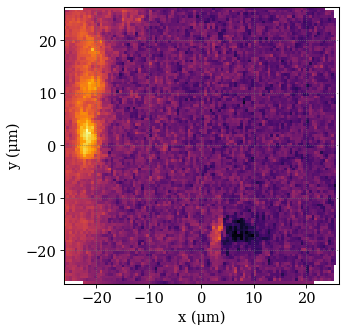

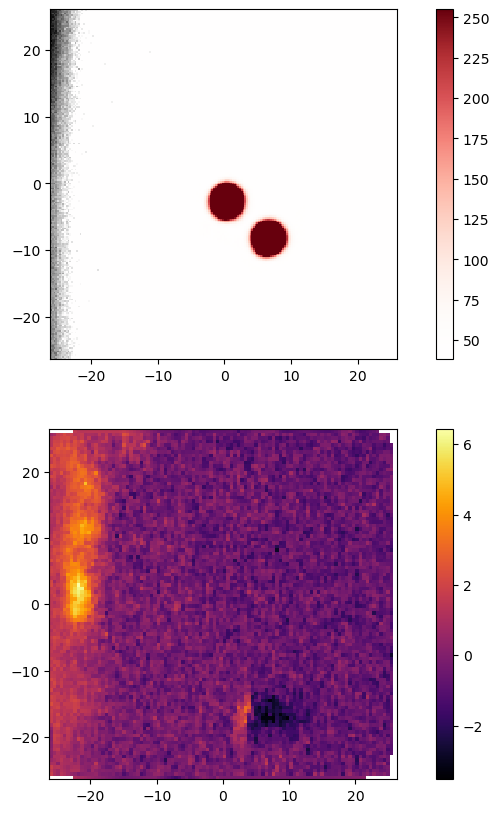

In [6]:
ds0 = collect_wfscan(nx,ny,ΔVx,ΔVy,Vx0,Vy0,fsamp,name=filename,sample_dir=sample_dir,wf_exposure_time=99*u.ms)
fig = plot_scan_data(ds0, wf_cmap=cm.gray, laser_cmap=cm.Reds, srs_cmap=cm.inferno)

# Manual widefield image+ scan

scan time: 900.00 second


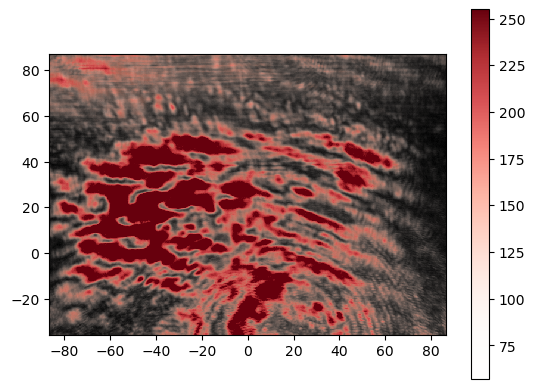

In [14]:
sample_dir= "diamond_SRL_GSDev1a_OEland1075.6-70mW_Nikon20x" 
filename = "Dev1a-1255.81_300uV3ms_1V150N_maxUp"

t_LIA = 3*u.ms
nx, ny      =   150   ,   150 #500          ,       500
ΔVx, ΔVy    =   1.0*u.volt   ,   1.0*u.volt #1.0*u.volt    ,      1.0*u.volt # 0.8*u.volt
fsamp       =   (1/(4*t_LIA)).to(u.Hz)#1000*u.Hz

fig = preview_scan_area(nx, ny, ΔVx, ΔVy, fsamp=fsamp, exposure_time=81*u.ms)

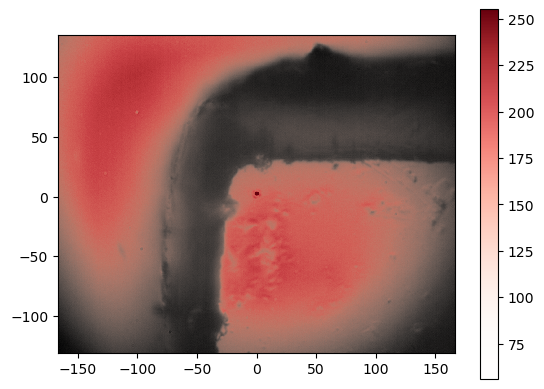

In [4]:
# Take laser spot and widefield image
wf_img, laser_spot_img = wf_and_laser_spot_images(exposure_time=81*u.ms)
fig = plot_laser_widefield_img(wf_img, laser_spot_img)

saving data to: 
C:\Users\euyehara\Documents\data\srs_microscope\Sample_diamond_SRL_GSDev1a_OEland1075.6-70mW_Nikon20x_2025-03-21-20-29-02\GalvoScan_Dev1a-1255.81_300uV3ms_1V150N_maxUp_2025-03-21-22-26-34.h5
dumping item: wf_img
dumping item: laser_spot_img
dumping item: dx_dpix
non-array, non-list item with units:
micrometer
dumping item: x_img
dumping item: y_img
dumping item: dx_dVx
non-array, non-list item with units:
micrometer / volt
dumping item: dy_dVy
non-array, non-list item with units:
micrometer / volt
dumping item: Vx0
non-array, non-list item with units:
volt
dumping item: Vy0
non-array, non-list item with units:
volt
scan time: 900.00 second
start time: Fri Mar 21 22:26:34 2025
stop time: Fri Mar 21 22:41:34 2025
dumping item: Dev1/ao0
dumping item: Dev1/ao1
dumping item: Dev1/ao2
dumping item: Dev1/ao3
dumping item: Dev1/ai0
dumping item: Dev1/ai2
dumping item: Dev1/ai3
dumping item: t
dumping item: Vx
dumping item: Vy
dumping item: dx_dVx
non-array, non-list item with 

C:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\matplotlib\cbook.py:733: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  x = np.array(x, subok=True, copy=copy)


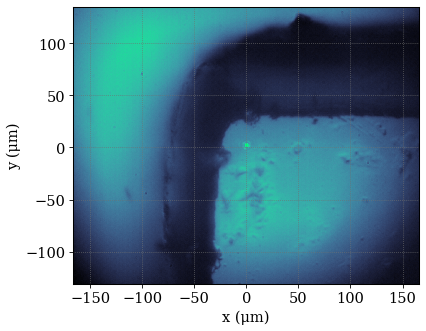

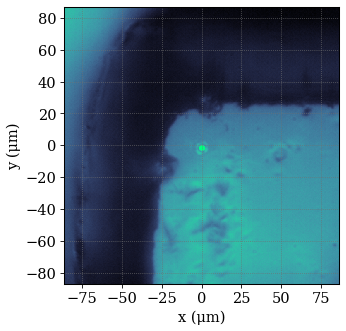

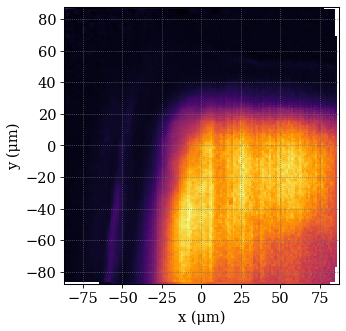

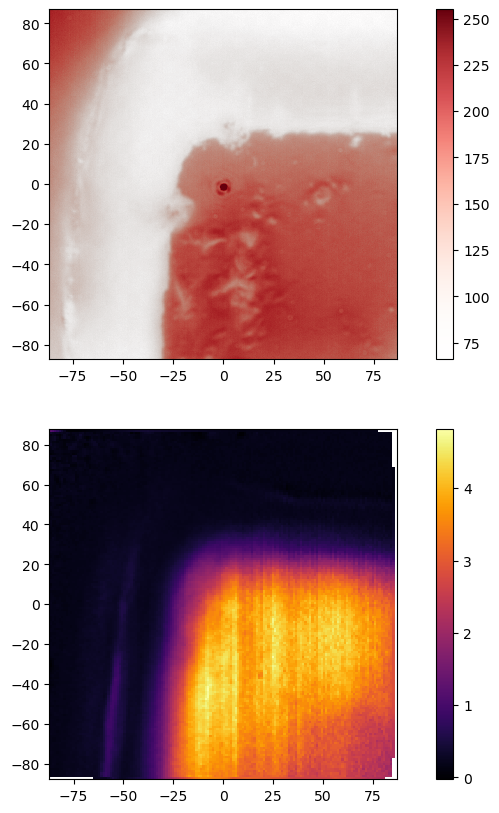

In [15]:
ds0 = collect_scan(nx,ny,ΔVx,ΔVy,Vx0,Vy0,fsamp,wf_img,laser_spot_img,name=filename,sample_dir=sample_dir)
fig = plot_scan_data(ds0, wf_cmap=cm.binary, laser_cmap=cm.Reds, srs_cmap=cm.inferno)